In [ ]:
import pandas as pd
from pathlib import Path

ROOT = Path.home() / "Documents" / "Projects" / "cassava-lead-disease-classification" 
df = pd.read_csv(ROOT / "train.csv")
print(len(df))
print(df.label.value_counts(normalize=True).sort_index())

21397
label
0    0.050802
1    0.102304
2    0.111511
3    0.614946
4    0.120437
Name: proportion, dtype: float64


(800, 600) (800, 600)


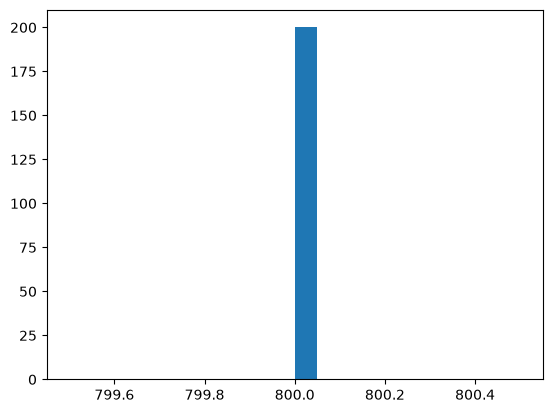

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

sample = df.image_id.sample(200, random_state=0)
sizes = [Image.open(ROOT / 'src' / 'data' / 'train_images' / f).size for f in sample]
widths, heights = zip(*sizes)
plt.hist(widths, bins=20)
print(min(sizes), max(sizes))

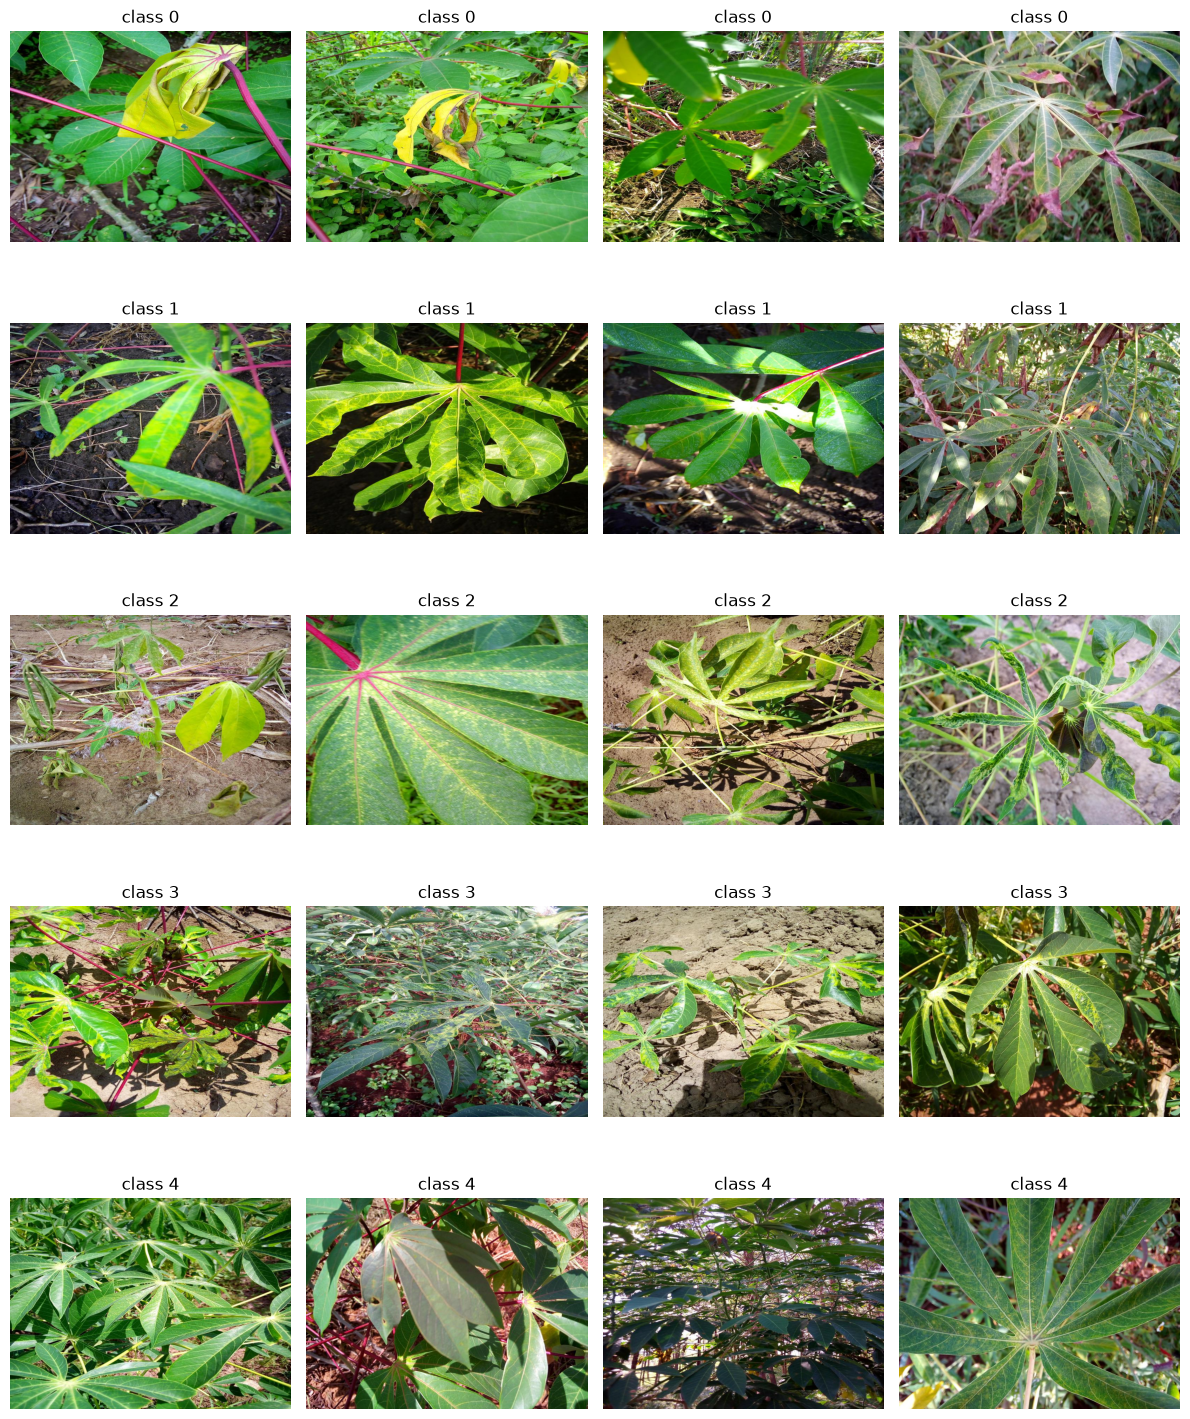

In [4]:
fig, axes = plt.subplots(5, 4, figsize=(12, 15))
for label in range(5):
    rows = df[df.label == label].sample(4, random_state=0)
    for ax, img_id in zip(axes[label], rows.image_id):
        ax.imshow(Image.open(ROOT / 'src' / 'data' / 'train_images' / img_id))
        ax.set_title(f"class {label}")
        ax.axis("off")
plt.tight_layout()

In [ ]:
broken = []
for img_id in df.image_id:
    try:
        Image.open(ROOT / 'src' / 'data' / 'train_images' / img_id).load()
    except Exception as e:
        broken.append((img_id, str(e)))
print(len(broken), broken[:5])

In [6]:
import numpy as np

p = df.label.value_counts(normalize=True).sort_index().to_numpy()
entropy = -(p * np.log(p)).sum()
print(entropy)
print(np.log(5))

1.1831477073395114
1.6094379124341003


In [9]:
import hashlib
from collections import defaultdict

groups = defaultdict(list)
for img_id in df.image_id:
    with open(ROOT / 'src' / 'data' / 'train_images' / img_id, "rb") as f:
        digest = hashlib.file_digest(f, "md5").hexdigest()
    groups[digest].append(img_id)

dup_groups = {h: ids for h, ids in groups.items() if len(ids) > 1}
G = len(dup_groups)
N1 = sum(len(ids) for ids in dup_groups.values())
print(G, N1)

0 0


In [ ]:
import imagehash
from PIL import Image

phashes = {img_id: imagehash.phash(Image.open(ROOT / 'src' / 'data' / 'train_images' / img_id)) for img_id in df.image_id.sample(2000, random_state=0)}
ids = list(phashes)
close_pairs = [(a, b) for i, a in enumerate(ids) for b in ids[i+1:] if phashes[a] - phashes[b] <= 5]
print(len(close_pairs))

0
